# v3 dose-response replay: **peak amplitude** instead of AUC

Counterfactual analysis of the v3 single-pulse ERK dose-response run
(`2026-05-11_bo_erk_dose_response_v3_hill_baseline08`). That run used
`mean_delta_auc` (per-cell trapezoid of `cnr - baseline`, averaged over a
FOV's cells) as the readout, and a MaxVar pure-exploration BO to resolve a
**Hill** dose-response curve over `pulse_duration` (25-5000 ms).

**Question.** Would a simpler readout -- the per-cell **peak amplitude**
(`max(cnr - baseline)` over the observation window, averaged over cells) --
have resolved the dose-response *better*?

**How (a replay, in the spirit of `regenerate_live_plot_v13.py`).** We do
not re-run the microscope. We replay the BO offline on the **doses the run
actually probed**, recomputing the readout two ways from the raw per-cell
tracks, and at each phase we refit the *real* Hill-mean `gpax.ExactGP`
(same kernel, same lengthscale prior, same HMC budget, same per-phase RNG
seeds the live agent used). Only the plotting is ours. For each readout we
track, per phase:

* the GP dose-response curve (posterior mean +/- 1 SD), and the measured FOVs;
* the **Hill `K` (EC50) posterior** in ms -- the parameter the run existed to infer;
* the GP's **median predictive variance** on the data -- the quantity the
  MaxVar acquisition actually minimises, so "lower = the readout let the BO
  resolve the curve with less residual uncertainty".

**Caveat (read this).** The replay uses the *same doses the AUC-driven run
chose*. A real peak-amplitude run would have a different MaxVar surface and
could probe different doses. So this answers **"is peak a cleaner readout on
matched sampling?"**, not the full counterfactual sampling trajectory. The
latter needs a forward simulation with a surrogate (out of scope here).

## Imports and gpax/numpyro setup

In [1]:
from __future__ import annotations

import os
import logging

# --- gpax/numpyro haiku shim (must run before `import gpax`) ----------------
# numpyro >= 0.20 removed random_haiku_module, which gpax 0.1.9 imports eagerly
# via viDKL. We never use viDKL (only ExactGP), so stub it to raise only if
# actually called. Same shim as the agent and regenerate_live_plot_v13.py.
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_a, **_k):
    raise NotImplementedError("haiku removed from numpyro >= 0.20; viDKL unavailable.")


for _name in ("random_haiku_module", "haiku_module"):
    if not hasattr(_ncm, _name):
        setattr(_ncm, _name, _haiku_unavailable)
# ---------------------------------------------------------------------------

os.environ.setdefault("JAX_LOG_COMPILES", "0")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gpax
import gpax.utils

gpax.utils.enable_x64()  # gpax 0.1.9 float32 Cholesky -> NaN; the agent does this too.

import numpyro.distributions as dist

for _n in list(logging.Logger.manager.loggerDict):
    if "jax" in _n or "absl" in _n:
        logging.getLogger(_n).setLevel(logging.WARNING)

# The REAL Hill mean function + prior + scaler the v3 agent used. Importing
# them (rather than re-deriving) is what keeps the replay faithful.
from faro.agents.two_task_dose_response import hill_mean_fn, hill_mean_fn_prior
from faro.agents.bo_optimization import StandardScalerBounds

print("gpax", gpax.__version__, "| x64 enabled")

gpax 0.1.9 | x64 enabled


## Configuration (mirrors the v3 run)

In [ ]:
RUN_DIR = r"E:/Alex/2026-05-11_bo_erk_dose_response_v3_hill_baseline08"

# --- per-FOV readout extraction (must match TwoTaskDoseResponseBO) ---
N_FRAMES_BASELINE = 5  # baseline = fov_timestep < 5
N_FRAMES = 31  # 5 baseline + 1 stim + 25 observation
STIM_FRAME = N_FRAMES_BASELINE  # 0-based index of the single stim frame
OBS_START = STIM_FRAME + 1  # observation window [6, 31)
OBS_END = N_FRAMES
MIN_TRACK_FRACTION = 0.8  # cell needs >= int(0.8*31)=24 tracked frames
MAX_BASELINE_CNR = 0.8  # drop cells whose baseline mean cnr >= 0.8
MIN_VALID_CELLS = 3  # drop FOV if fewer than 3 cells survive

# --- BO / GP configuration (v3 cell 15) ---
DOSE_BOUNDS = (0.0, 5000.0)
DOSE_SPACING = 20.0
COVARIATES = [
    ("optortk_expression", True),
    ("baseline_cnr", False),
]  # (name, log_scale)
GP_KERNEL = "Matern"
LENGTHSCALE_PRIOR = dist.Uniform(0.1, 5.0)
RNG_SEED = 42
N_COND_PER_PHASE = 3  # 3 new doses per phase
N_PHASES = 8

# HMC budget. v3 used 400 / 800. Set env PEAK_REPLAY_FAST=1 for a quick look
# (the AUC-vs-peak conclusion is robust to the budget; only MCMC noise changes).
if os.environ.get("PEAK_REPLAY_FAST"):
    GP_NUM_WARMUP, GP_NUM_SAMPLES = 150, 250
    print("FAST mode: HMC 150/250 (not the v3 400/800)")
else:
    GP_NUM_WARMUP, GP_NUM_SAMPLES = 400, 800

# The two readouts we compare. AUC is the original objective.
READOUTS = {
    "AUC (mean_delta_auc)": "mean_delta_auc",
    "peak amplitude (mean_peak_amp)": "mean_peak_amp",
}


# Shifted-dose [0, 2] -> ms (StandardScalerBounds maps [25,5000] -> [-1,1],
# hill_mean_fn shifts by +1). Used to read the Hill K posterior in ms.
def shifted_to_ms(d):
    return np.asarray(d) / 2.0 * (DOSE_BOUNDS[1] - DOSE_BOUNDS[0]) + DOSE_BOUNDS[0]

## Step 1 - recompute both readouts from the raw per-cell tracks

`fov_objectives` reproduces `TwoTaskDoseResponseBO._preprocess_results`
exactly (same per-cell filtering: track-length >= 0.8, baseline cnr < 0.8,
>= 3 surviving cells, baseline window `< 5`, observation window `[6, 31)`),
then computes both per-FOV summaries from the *same* surviving cells:

* `mean_delta_auc` = mean over cells of `trapezoid(cnr - baseline)` (original);
* `mean_peak_amp`  = mean over cells of `max(cnr - baseline)` (the candidate).

In [3]:
exp = pd.read_parquet(os.path.join(RUN_DIR, "exp_data.parquet"))
print(
    "exp_data:",
    exp.shape,
    "| (phase_id, fov) groups:",
    exp.groupby(["phase_id", "fov"]).ngroups,
)


def fov_objectives(df_fov):
    """Per-FOV AUC + peak amplitude with the v3 per-cell filtering."""
    cnr_col = "cnr" if "cnr" in df_fov.columns else "cnr_median"
    all_particles = df_fov["particle"].unique()
    min_frames = int(MIN_TRACK_FRACTION * N_FRAMES)
    frames_per_cell = df_fov.groupby("particle")["fov_timestep"].nunique()

    baseline_df = df_fov[df_fov["fov_timestep"] < N_FRAMES_BASELINE]
    per_cell_baseline = baseline_df.groupby("particle")[cnr_col].mean().dropna()
    baseline_cnr_fov = (
        float(per_cell_baseline.mean()) if len(per_cell_baseline) else 0.0
    )

    valid = set(all_particles)
    valid &= set(frames_per_cell[frames_per_cell >= min_frames].index)
    if len(per_cell_baseline):
        valid &= set(per_cell_baseline[per_cell_baseline < MAX_BASELINE_CNR].index)

    aucs, peaks = [], []
    for particle, grp in df_fov.groupby("particle"):
        if particle not in valid:
            continue
        grp = grp.sort_values("fov_timestep")
        bl = grp[grp["fov_timestep"] < N_FRAMES_BASELINE]
        if bl.empty:
            continue
        baseline_val = float(bl[cnr_col].mean())
        obs = grp[(grp["fov_timestep"] >= OBS_START) & (grp["fov_timestep"] < OBS_END)]
        if len(obs) < 3:
            continue
        t = obs["fov_timestep"].to_numpy(float)
        delta = obs[cnr_col].to_numpy(float) - baseline_val
        aucs.append(float(np.trapezoid(delta, t)))
        peaks.append(float(np.max(delta)))

    n_cells = len(valid)
    if n_cells < MIN_VALID_CELLS or len(aucs) == 0:
        return None

    s = df_fov.groupby("particle")["ref_mean_intensity"].first().dropna()
    s = s[s > 0]
    return dict(
        n_cells=float(n_cells),
        baseline_cnr=baseline_cnr_fov,
        optortk_expression=float(s.mean()) if len(s) else 0.0,
        mean_delta_auc=float(np.mean(aucs)),
        mean_peak_amp=float(np.mean(peaks)),
    )


rows = []
for (pid, fov), g in exp.groupby(["phase_id", "fov"]):
    o = fov_objectives(g)
    if o is None:
        continue
    o.update(
        phase_id=int(pid),
        fov=int(fov),
        pulse_duration=float(g["pulse_duration"].iloc[0]),
    )
    rows.append(o)

res = pd.DataFrame(rows).sort_values(["phase_id", "fov"]).reset_index(drop=True)
print("recomputed per-FOV rows:", len(res))
res.head()

exp_data: (521102, 33) | (phase_id, fov) groups: 144


recomputed per-FOV rows: 144


,n_cells,baseline_cnr,optortk_expression,mean_delta_auc,mean_peak_amp,phase_id,fov,pulse_duration
0,37.0,0.503457,1808.417424,1.877316,0.212185,0,0,450.0
1,79.0,0.575819,1907.463357,3.854704,0.413189,0,1,450.0
2,88.0,0.609587,1785.145900,2.610569,0.282144,0,2,450.0
3,30.0,0.660972,1820.833807,1.903921,0.216113,0,3,450.0
4,71.0,0.556945,1977.755388,3.837293,0.382446,0,4,450.0


## Step 2 - sanity check: our recomputed AUC matches the run's checkpoint

If our per-cell pipeline reproduces the agent's `mean_delta_auc`, then the
`mean_peak_amp` we computed from the *same surviving cells* is trustworthy.

matched 144/144 FOVs | max|diff|=1.46e-01 mean|diff|=5.21e-03 corr=0.999970


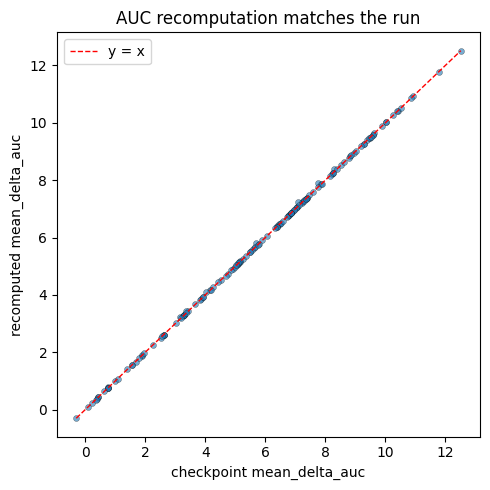

In [4]:
ck = pd.read_parquet(
    os.path.join(RUN_DIR, "checkpoints", "bo_results_phase_007.parquet")
)

a = res[["pulse_duration", "n_cells", "baseline_cnr", "mean_delta_auc"]].copy()
b = ck[["pulse_duration", "n_cells", "baseline_cnr", "mean_delta_auc"]].copy()
# Join on (dose, surviving-cell count, baseline cnr) -- effectively a per-FOV key.
for d in (a, b):
    d["key"] = list(zip(d.pulse_duration.round(3), d.n_cells, d.baseline_cnr.round(5)))
m = a.merge(b, on="key", suffixes=("_mine", "_ck")).drop_duplicates("key")
diff = (m.mean_delta_auc_mine - m.mean_delta_auc_ck).abs()
print(
    f"matched {len(m)}/{len(ck)} FOVs | max|diff|={diff.max():.2e} "
    f"mean|diff|={diff.mean():.2e} corr={np.corrcoef(m.mean_delta_auc_mine, m.mean_delta_auc_ck)[0,1]:.6f}"
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    m.mean_delta_auc_ck,
    m.mean_delta_auc_mine,
    s=18,
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3,
)
lims = [
    min(m.mean_delta_auc_ck.min(), m.mean_delta_auc_mine.min()),
    max(m.mean_delta_auc_ck.max(), m.mean_delta_auc_mine.max()),
]
ax.plot(lims, lims, "r--", lw=1, label="y = x")
ax.set_xlabel("checkpoint mean_delta_auc")
ax.set_ylabel("recomputed mean_delta_auc")
ax.set_title("AUC recomputation matches the run")
ax.legend()
plt.tight_layout()
plt.show()

## Step 2b - the two readouts, side by side (all 144 FOVs)

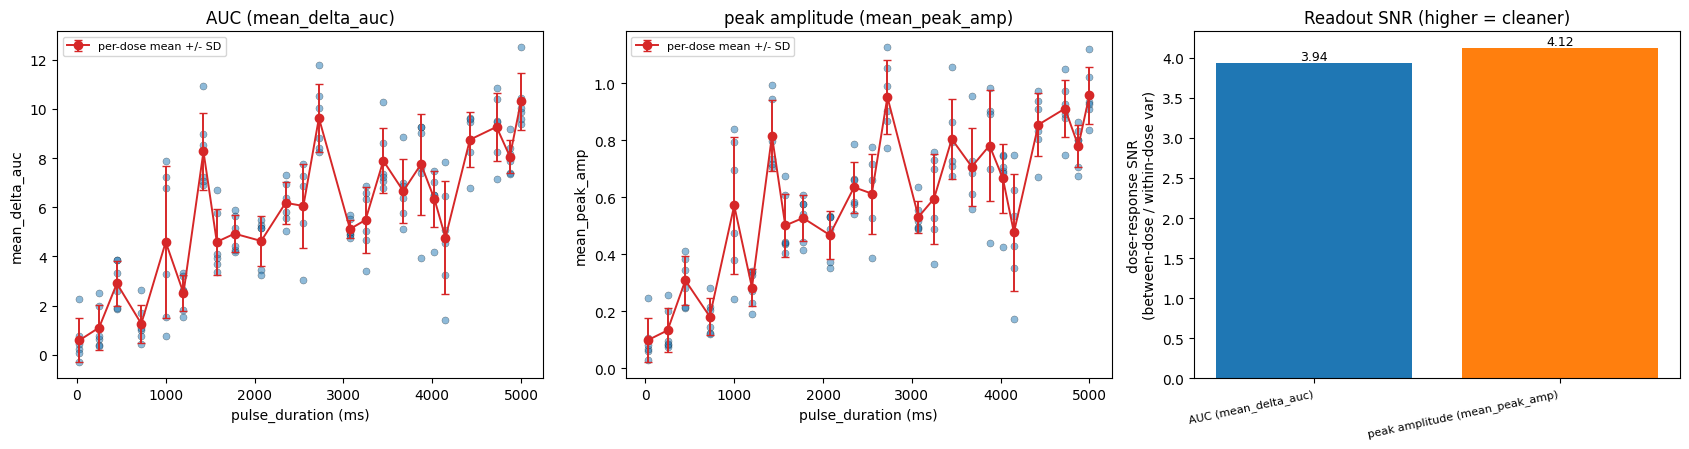

SNR: {'AUC (mean_delta_auc)': 3.939, 'peak amplitude (mean_peak_amp)': 4.125}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

for ax, (label, col) in zip(axes[:2], READOUTS.items()):
    ax.scatter(
        res.pulse_duration, res[col], s=26, alpha=0.5, edgecolors="k", linewidths=0.3
    )
    agg = res.groupby("pulse_duration")[col].agg(["mean", "std", "count"]).reset_index()
    ax.errorbar(
        agg.pulse_duration,
        agg["mean"],
        yerr=agg["std"].fillna(0),
        fmt="o-",
        color="C3",
        capsize=3,
        lw=1.4,
        label="per-dose mean +/- SD",
    )
    ax.set_xlabel("pulse_duration (ms)")
    ax.set_ylabel(col)
    ax.set_title(label)
    ax.legend(fontsize=8)


# Readout SNR = between-dose signal variance / mean within-dose (FOV) variance.
# Scale-free, so AUC and peak are directly comparable; higher = cleaner curve.
def readout_snr(col):
    g = res.groupby("pulse_duration")[col]
    between = float(np.var(g.mean().to_numpy(), ddof=1))
    within = float(np.nanmean(g.var(ddof=1).to_numpy()))
    return between / within if within > 0 else np.nan


snr = {label: readout_snr(col) for label, col in READOUTS.items()}
ax = axes[2]
ax.bar(range(len(snr)), list(snr.values()), color=["C0", "C1"])
ax.set_xticks(range(len(snr)))
ax.set_xticklabels(list(snr), rotation=12, ha="right", fontsize=8)
ax.set_ylabel("dose-response SNR\n(between-dose / within-dose var)")
ax.set_title("Readout SNR (higher = cleaner)")
for i, v in enumerate(snr.values()):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print("SNR:", {k: round(v, 3) for k, v in snr.items()})

## Step 3 - the offline replay machinery

`fit_hill_gp` is the agent's `_fit_candidate` for the single Hill candidate
(same kernel, lengthscale prior, HMC budget, jitter). `predict_curve`
mirrors the agent's `_plot_1d_landscape`: predict over the full 200-point
dose grid with covariates fixed at their median, in the readout's own units.
`median_pred_var` is the agent's `_median_predictive_variance` -- the MaxVar
reward signal, in standardised-y units (comparable across readouts).

In [6]:
COV_NAMES = [c for c, _ in COVARIATES]
X_COLS = ["pulse_duration"] + COV_NAMES
BOUNDS = [DOSE_BOUNDS] + [None for _ in COVARIATES]
LOG_SCALE = [False] + [lg for _, lg in COVARIATES]
DOSE_GRID = np.arange(DOSE_BOUNDS[0], DOSE_BOUNDS[1] + 1e-6, DOSE_SPACING)


def fit_x_scaler(df):
    sc = StandardScalerBounds()
    x = sc.fit_transform(df[X_COLS].to_numpy(float), bounds=BOUNDS, log_scale=LOG_SCALE)
    return jnp.asarray(x), sc


def fit_hill_gp(x, y, rng_key):
    """Faithful copy of TwoTaskDoseResponseBO._fit_candidate for the Hill candidate."""
    gp = gpax.ExactGP(
        input_dim=x.shape[1],
        kernel=GP_KERNEL,
        mean_fn=hill_mean_fn,
        mean_fn_prior=hill_mean_fn_prior,
        lengthscale_prior_dist=LENGTHSCALE_PRIOR,
    )
    gp.fit(
        rng_key,
        X=x,
        y=y,
        progress_bar=False,
        num_warmup=GP_NUM_WARMUP,
        num_samples=GP_NUM_SAMPLES,
        print_summary=False,
        jitter=1e-4,
    )
    return gp


def predict_curve(gp, x_scaler, y_scaler, cov_med, rng_key):
    """Posterior mean +/- 1 SD over the dose grid, in original readout units."""
    x_raw = np.column_stack([DOSE_GRID, np.tile(cov_med, (len(DOSE_GRID), 1))])
    x_scaled = x_scaler.transform(x_raw)
    mean_s, samp = gp.predict_in_batches(
        rng_key, jnp.asarray(x_scaled), batch_size=50, n=4, noiseless=True
    )
    mean_s = np.asarray(mean_s).ravel()
    sd_s = np.asarray(samp).reshape(-1, len(DOSE_GRID)).std(0)
    inv = lambda v: y_scaler.inverse_transform(np.asarray(v).reshape(-1, 1)).ravel()
    return inv(mean_s), inv(mean_s - sd_s), inv(mean_s + sd_s)


def median_pred_var(gp, x_train, rng_key):
    """Agent's _median_predictive_variance: the MaxVar reward (standardised-y units)."""
    _, samp = gp.predict(rng_key, jnp.asarray(x_train), n=4, noiseless=True)
    arr = np.asarray(samp).reshape(-1, np.asarray(samp).shape[-1])
    return float(np.nanmedian(arr.var(0)))

### Run the replay

For each readout, we refit the Hill-GP on a growing prefix of the data
(`k = 1 .. 8` phases, i.e. the 18, 36, ... 144 FOVs available after each
phase), using the same per-phase RNG seed (`RNG_SEED + k`) the live agent
used. This reproduces saved models `bo_model_iter_001..007`; `k = 8` is the
final fit on the complete dataset (never fit live).

In [7]:
phases = sorted(res.phase_id.unique())
replay = {label: [] for label in READOUTS}  # per readout: list of per-k dicts

for k in range(1, N_PHASES + 1):
    sub = res[res.phase_id < k]  # first k phases of data
    if sub.empty:
        continue
    x, x_scaler = fit_x_scaler(sub)
    cov_med = np.median(sub[COV_NAMES].to_numpy(float), axis=0)
    key_fit, key_pred = gpax.utils.get_keys(RNG_SEED + k)

    for label, col in READOUTS.items():
        y_scaler = StandardScalerBounds()
        y = y_scaler.fit_transform(
            sub[col].to_numpy(float).reshape(-1, 1), bounds=None, log_scale=[False]
        )
        gp = fit_hill_gp(x, jnp.asarray(y).ravel(), key_fit)
        mean_o, lo_o, hi_o = predict_curve(gp, x_scaler, y_scaler, cov_med, key_pred)
        K_ms = shifted_to_ms(np.asarray(gp.get_samples()["hill_k"]))
        n_post = np.asarray(gp.get_samples()["hill_n"])
        replay[label].append(
            dict(
                k=k,
                n_fovs=len(sub),
                n_doses=sub.pulse_duration.nunique(),
                df=sub,
                col=col,
                mean=mean_o,
                lo=lo_o,
                hi=hi_o,
                K_ms=K_ms,
                n_post=n_post,
                K_med=float(np.median(K_ms)),
                K_lo=float(np.percentile(K_ms, 25)),
                K_hi=float(np.percentile(K_ms, 75)),
                med_var=median_pred_var(gp, x, key_pred),
            )
        )
    print(
        f"phase prefix k={k}: {len(sub)} FOVs, {sub.pulse_duration.nunique()} doses  (both readouts fit)"
    )
print("replay complete.")

phase prefix k=1: 18 FOVs, 3 doses  (both readouts fit)


phase prefix k=2: 36 FOVs, 6 doses  (both readouts fit)


phase prefix k=3: 54 FOVs, 9 doses  (both readouts fit)


phase prefix k=4: 72 FOVs, 12 doses  (both readouts fit)


phase prefix k=5: 90 FOVs, 15 doses  (both readouts fit)


phase prefix k=6: 108 FOVs, 18 doses  (both readouts fit)


phase prefix k=7: 126 FOVs, 21 doses  (both readouts fit)


phase prefix k=8: 144 FOVs, 24 doses  (both readouts fit)
replay complete.


## Step 4 - per-phase landscape figures

One row per phase prefix. Left: AUC GP curve. Middle: peak-amplitude GP
curve. Right: Hill `K` (EC50) posterior in ms for both readouts -- a
narrower, more stable distribution means that readout pinned down the
dose-response inflection more confidently.

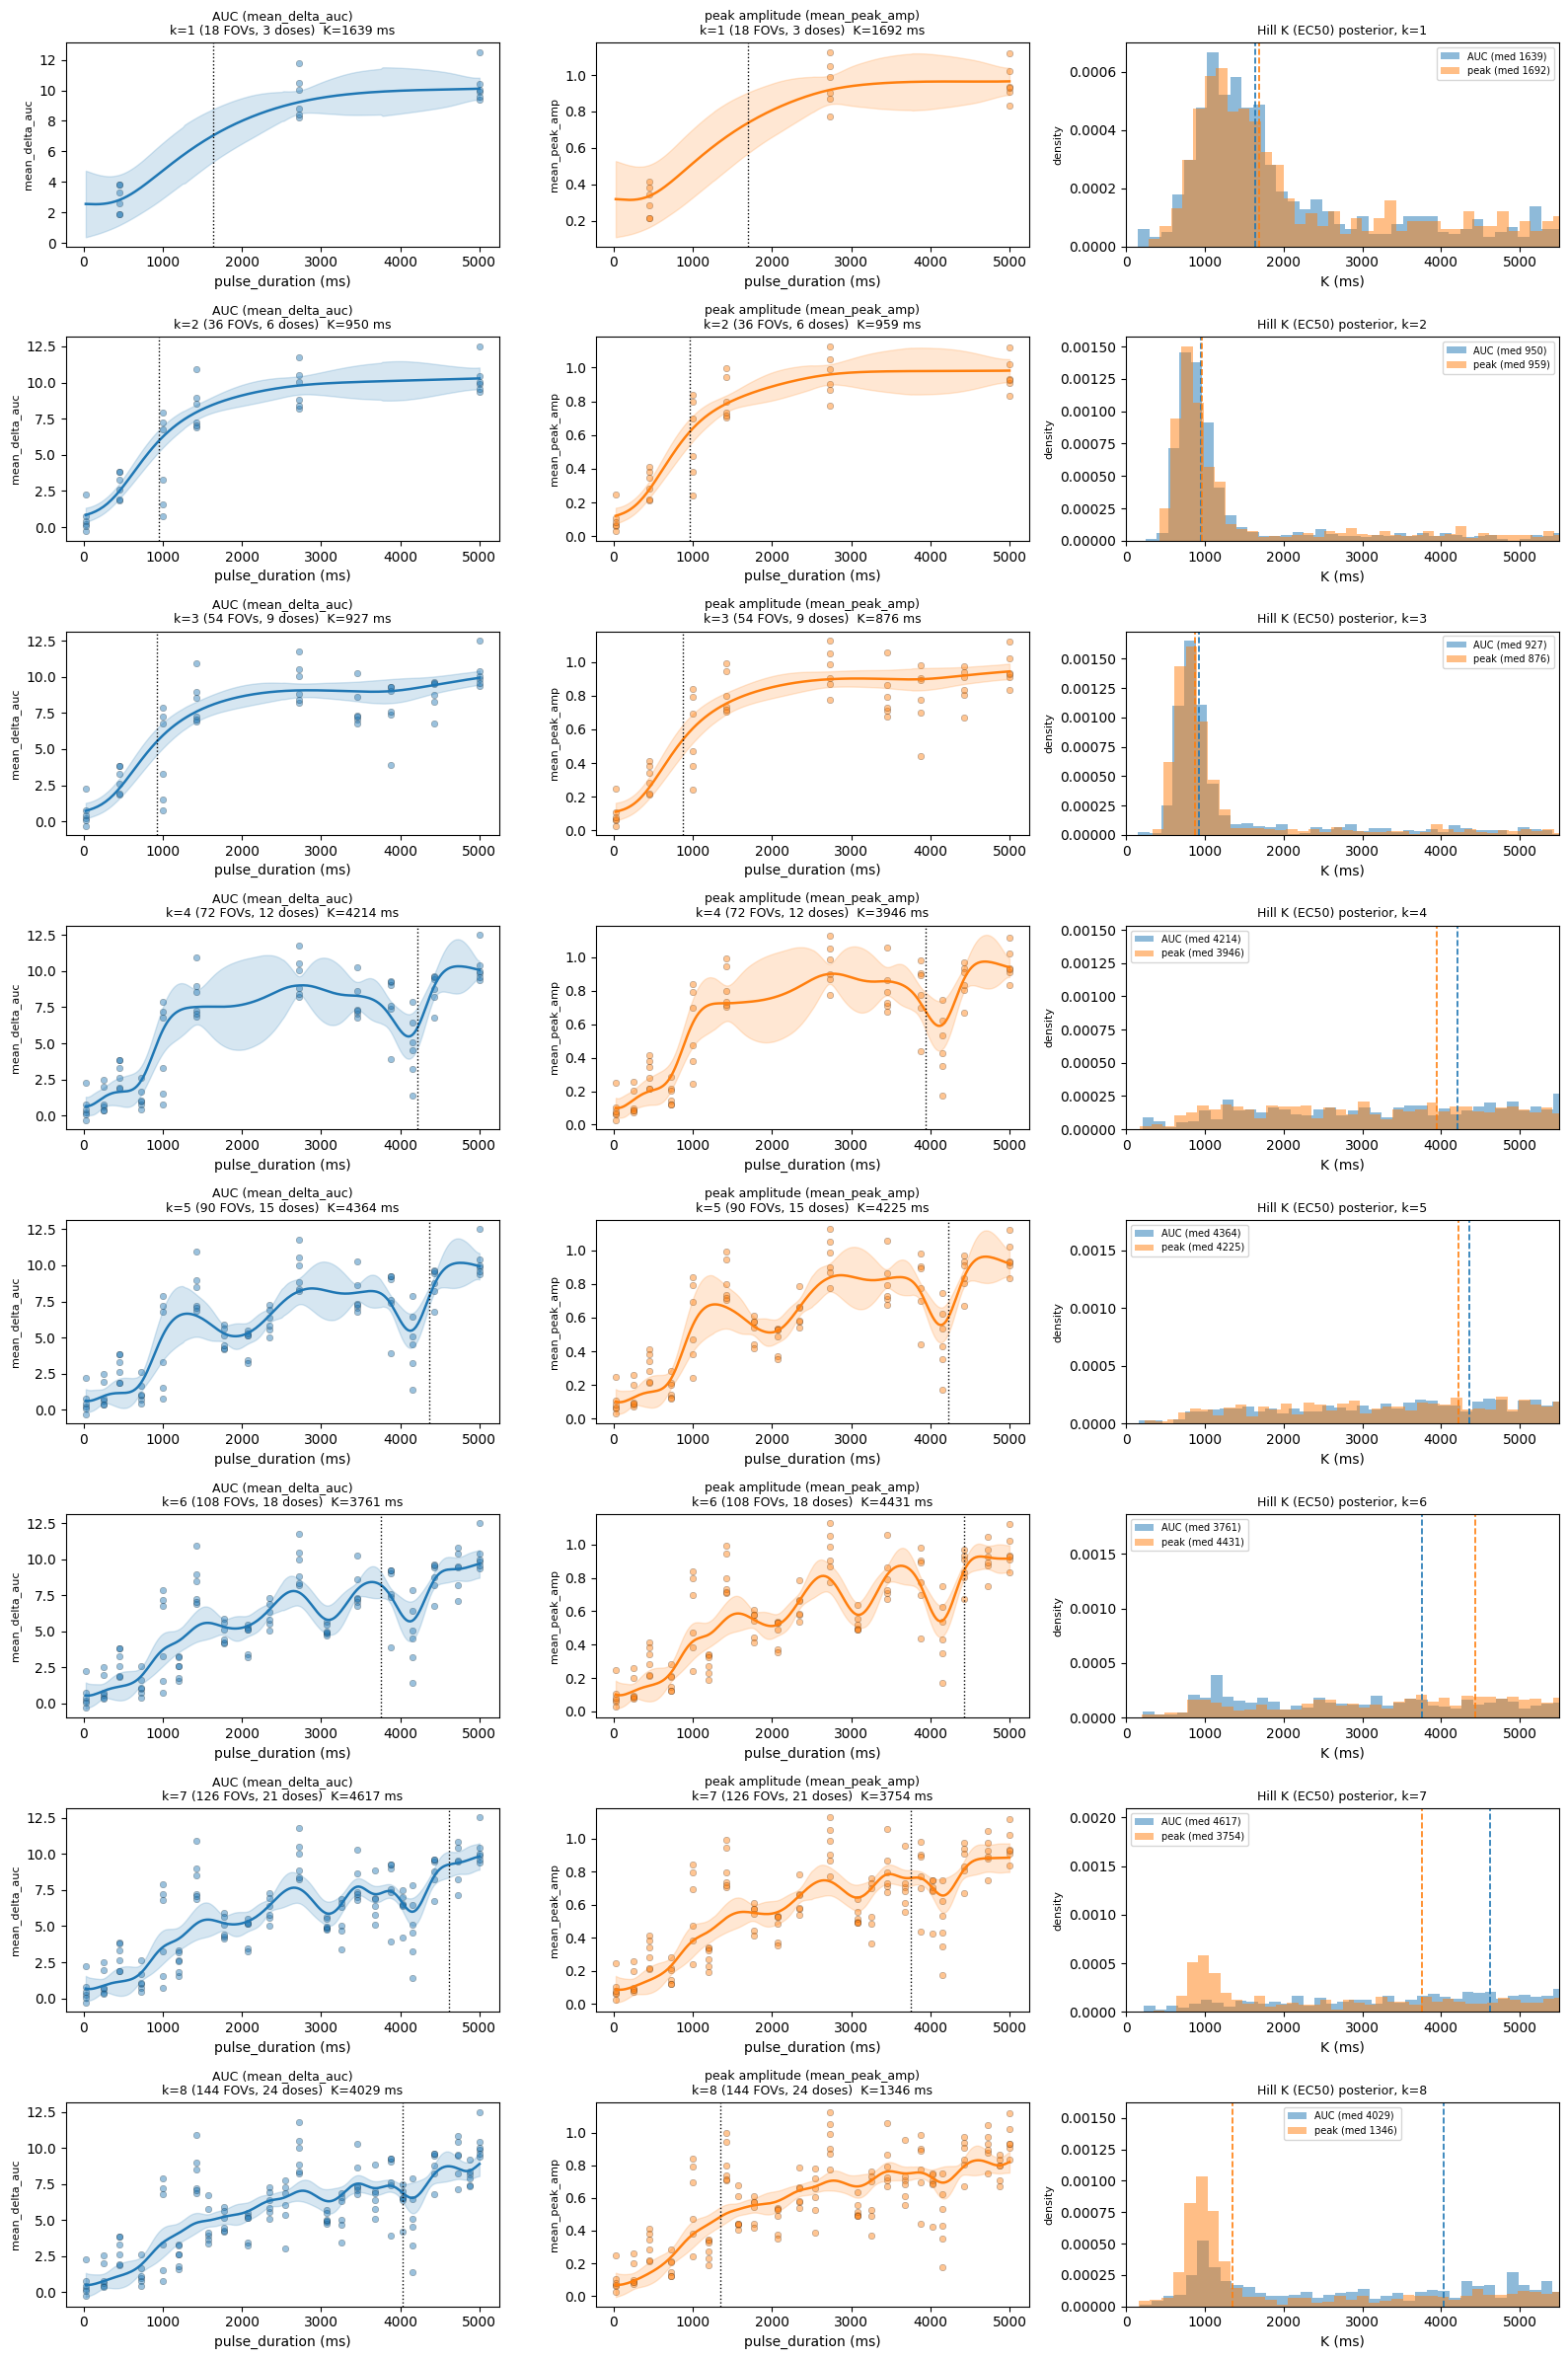

In [8]:
ks = [d["k"] for d in replay[list(READOUTS)[0]]]
n_rows = len(ks)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 3.0 * n_rows), squeeze=False)
colors = {list(READOUTS)[0]: "C0", list(READOUTS)[1]: "C1"}

for r, k in enumerate(ks):
    for c, (label, col) in enumerate(READOUTS.items()):
        d = replay[label][r]
        ax = axes[r][c]
        ax.scatter(
            d["df"].pulse_duration,
            d["df"][col],
            s=22,
            alpha=0.45,
            color=colors[label],
            edgecolors="k",
            linewidths=0.3,
        )
        ax.fill_between(DOSE_GRID, d["lo"], d["hi"], color=colors[label], alpha=0.18)
        ax.plot(DOSE_GRID, d["mean"], color=colors[label], lw=1.8)
        ax.axvline(d["K_med"], color="k", ls=":", lw=1)
        ax.set_title(
            f"{label}\nk={k} ({d['n_fovs']} FOVs, {d['n_doses']} doses)  "
            f"K={d['K_med']:.0f} ms",
            fontsize=9,
        )
        ax.set_xlabel("pulse_duration (ms)")
        ax.set_ylabel(col, fontsize=8)

    ax = axes[r][2]
    for label in READOUTS:
        d = replay[label][r]
        ax.hist(
            np.clip(d["K_ms"], 0, DOSE_BOUNDS[1] * 1.2),
            bins=40,
            alpha=0.5,
            color=colors[label],
            label=f"{label.split(' ')[0]} (med {d['K_med']:.0f})",
            density=True,
        )
        ax.axvline(d["K_med"], color=colors[label], ls="--", lw=1.2)
    ax.set_xlim(0, DOSE_BOUNDS[1] * 1.1)
    ax.set_title(f"Hill K (EC50) posterior, k={k}", fontsize=9)
    ax.set_xlabel("K (ms)")
    ax.set_ylabel("density", fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Step 5 - convergence summary: did peak amplitude resolve the curve better?

* **Left** -- Hill `K` (EC50) estimate vs phases, with the inter-quartile
  band. The headline: which readout converges to a stable EC50 sooner and
  with a tighter posterior.
* **Right** -- the GP's median predictive variance (the MaxVar reward, in
  standardised-y units). Lower at a given phase = the readout let the BO
  resolve the dose-response with less residual uncertainty = "worked better"
  in the BO's own terms.

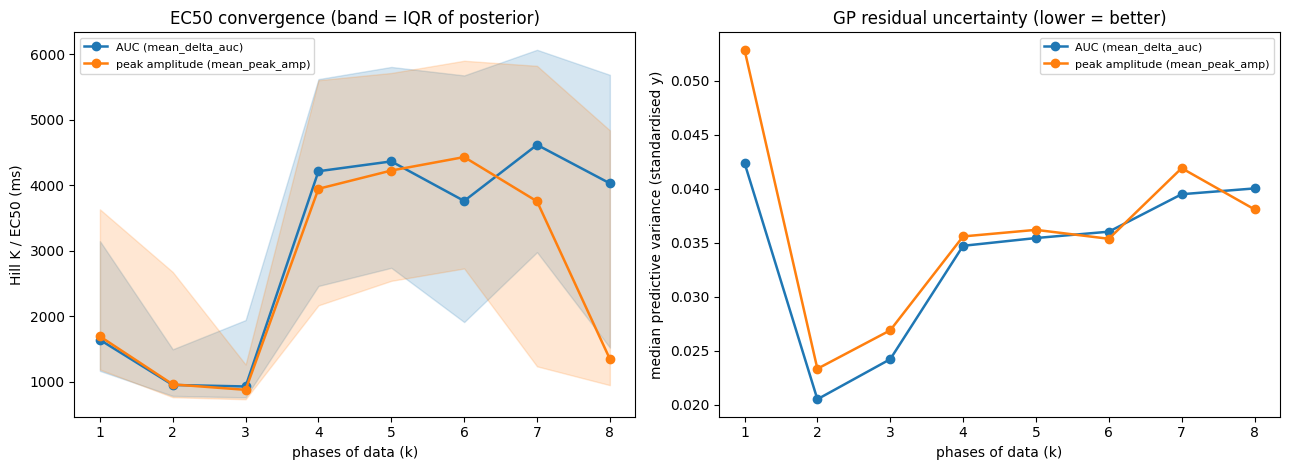

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
for label in READOUTS:
    ds = replay[label]
    ks_ = [d["k"] for d in ds]
    med = [d["K_med"] for d in ds]
    lo = [d["K_lo"] for d in ds]
    hi = [d["K_hi"] for d in ds]
    ax.plot(ks_, med, "o-", color=colors[label], label=label, lw=1.8)
    ax.fill_between(ks_, lo, hi, color=colors[label], alpha=0.18)
ax.set_xlabel("phases of data (k)")
ax.set_ylabel("Hill K / EC50 (ms)")
ax.set_title("EC50 convergence (band = IQR of posterior)")
ax.legend(fontsize=8)

ax = axes[1]
for label in READOUTS:
    ds = replay[label]
    ax.plot(
        [d["k"] for d in ds],
        [d["med_var"] for d in ds],
        "o-",
        color=colors[label],
        label=label,
        lw=1.8,
    )
ax.set_xlabel("phases of data (k)")
ax.set_ylabel("median predictive variance (standardised y)")
ax.set_title("GP residual uncertainty (lower = better)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 6 - data-driven verdict

In [10]:
def final(label, key):
    return replay[label][-1][key]


names = list(READOUTS)
print("=" * 70)
print("FINAL (k=8, all 144 FOVs):")
for label in names:
    d = replay[label][-1]
    print(
        f"  {label:34s}  K={d['K_med']:5.0f} ms  IQR=[{d['K_lo']:.0f},{d['K_hi']:.0f}] "
        f"(width {d['K_hi']-d['K_lo']:4.0f})  median_pred_var={d['med_var']:.4f}"
    )
print(
    f"  readout SNR (between/within dose):  "
    + "  ".join(f"{label.split(' ')[0]}={snr[label]:.2f}" for label in names)
)
print("=" * 70)

auc, peak = names[0], names[1]
verdict = []
# Tighter EC50?
wa = final(auc, "K_hi") - final(auc, "K_lo")
wp = final(peak, "K_hi") - final(peak, "K_lo")
verdict.append(
    (
        "EC50 posterior tighter",
        "peak" if wp < wa else "AUC",
        f"IQR {wp:.0f} vs {wa:.0f} ms",
    )
)
# Lower residual uncertainty?
verdict.append(
    (
        "lower GP residual var",
        "peak" if final(peak, "med_var") < final(auc, "med_var") else "AUC",
        f"{final(peak,'med_var'):.3f} vs {final(auc,'med_var'):.3f}",
    )
)
# Higher SNR?
verdict.append(
    (
        "higher dose-response SNR",
        "peak" if snr[peak] > snr[auc] else "AUC",
        f"{snr[peak]:.2f} vs {snr[auc]:.2f}",
    )
)


# EC50 stability over last 3 phases
def stab(label):
    last = [d["K_med"] for d in replay[label][-3:]]
    return float(np.std(last))


verdict.append(
    (
        "EC50 more stable (last 3 phases)",
        "peak" if stab(peak) < stab(auc) else "AUC",
        f"std {stab(peak):.0f} vs {stab(auc):.0f} ms",
    )
)

print("\nVERDICT (peak amplitude vs AUC, on the doses the run actually probed):")
peak_wins = 0
for crit, winner, detail in verdict:
    peak_wins += winner == "peak"
    print(f"  [{winner:4s}] {crit:34s}  ({detail})")
print(f"\n  peak amplitude wins {peak_wins}/{len(verdict)} criteria.")
print("  Reminder: matched-sampling readout comparison, NOT a counterfactual")
print("  re-sampling. A peak-driven MaxVar run could have probed other doses.")

FINAL (k=8, all 144 FOVs):
  AUC (mean_delta_auc)                K= 4029 ms  IQR=[1521,5686] (width 4166)  median_pred_var=0.0400
  peak amplitude (mean_peak_amp)      K= 1346 ms  IQR=[947,4838] (width 3891)  median_pred_var=0.0381
  readout SNR (between/within dose):  AUC=3.94  peak=4.12

VERDICT (peak amplitude vs AUC, on the doses the run actually probed):
  [peak] EC50 posterior tighter              (IQR 3891 vs 4166 ms)
  [peak] lower GP residual var               (0.038 vs 0.040)
  [peak] higher dose-response SNR            (4.12 vs 3.94)
  [AUC ] EC50 more stable (last 3 phases)    (std 1324 vs 358 ms)

  peak amplitude wins 3/4 criteria.
  Reminder: matched-sampling readout comparison, NOT a counterfactual
  re-sampling. A peak-driven MaxVar run could have probed other doses.
